In [4]:
import pandas as pd

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-900*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

2021-09-30 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


In [5]:

window_step_length = 6
window_size = 50
num_test_points = 900

horizon = 10 #3 is good
target_idx = 0



Shape dataset (6409, 11)
means:  Close           8.057271e+01
Volume          1.259072e+07
MarketCap       1.279897e+11
Weight          4.173304e-02
Return          6.364129e-04
LogReturn       4.338309e-04
WeightedRet     3.053555e-05
SMA20           8.022321e+01
EMA20           8.021005e+01
RSI14           5.253680e+01
ReturnVola20    1.835859e-02
dtype: float64
stds:  Close           6.781238e+01
Volume          1.708028e+07
MarketCap       1.077200e+11
Weight          1.297622e-02
Return          2.013867e-02
LogReturn       2.012149e-02
WeightedRet     8.541972e-04
SMA20           6.744902e+01
EMA20           6.737596e+01
RSI14           1.213508e+01
ReturnVola20    8.307794e-03
dtype: float64


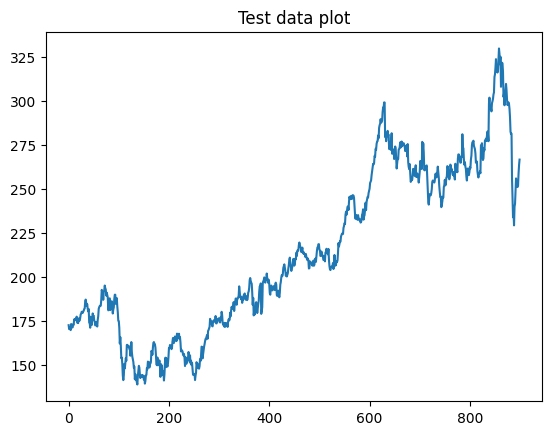

in sequences shape:  (909, 50, 11)
targets shape:  (909, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 2.659579567181715
Normalized Benchmark: 0.0670729270417313


/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ train │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  1.8 M │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

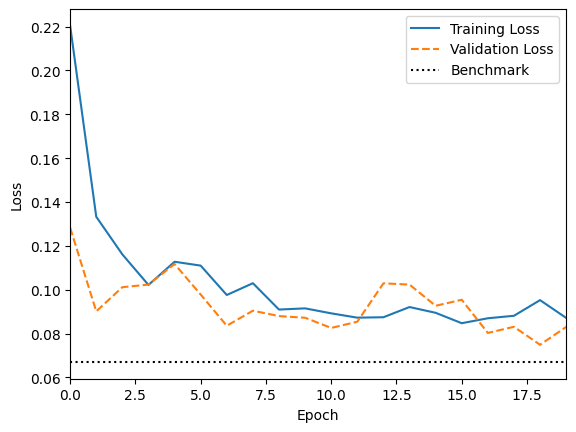

variance of returns for old data:  0.004008536141293924
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(170.9581)
period from idx:  0  to idx  10
prediction at 10:  tensor(176.3283)
last price from test data:  170.9580535888672
real price 10 steps forward:  tensor(172.7976)
kelly weight:  {tensor(7.8365, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.0779)
period from idx:  10  to idx  20
prediction at 10:  tensor(177.8220)
last price from test data:  tensor(173.0779)
real price 10 steps forward:  tensor(176.4680)
kelly weight:  {tensor(6.8379, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.7962)
period from idx:  20  to idx  30
prediction at 10:  tensor(179.7765)
last price from test data:  tensor(173.7962)
real price 10 steps forward:  tensor(180.8042)
kelly weight:  {tensor(8.5841, dtype=torch.flo

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(181.0669)
period from idx:  80  to idx  90
prediction at 10:  tensor(188.8694)
last price from test data:  tensor(181.0669)
real price 10 steps forward:  tensor(182.7313)
kelly weight:  {tensor(10.7499, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(181.5049)
period from idx:  90  to idx  100
prediction at 10:  tensor(190.2845)
last price from test data:  tensor(181.5049)
real price 10 steps forward:  tensor(174.9350)
kelly weight:  {tensor(12.0670, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(175.1453)
period from idx:  100  to idx  110
prediction at 10:  tensor(184.1405)
last price from test data:  tensor(175.1453)
real price 10 steps forward:  tensor(144.0302)
kelly weight:  {tensor(12.8124, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(141.3846)
period from idx:  110  to idx  120
prediction 

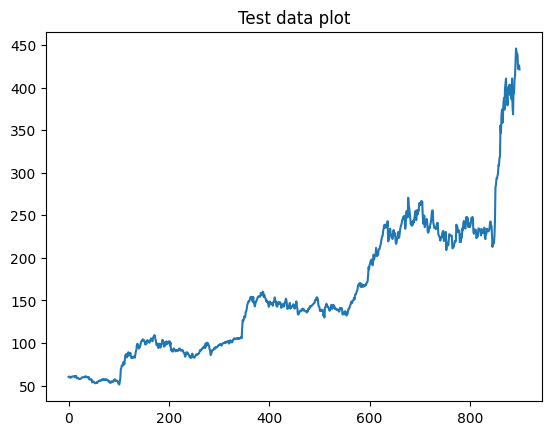

in sequences shape:  (909, 50, 11)
targets shape:  (909, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.5363558821080705
Normalized Benchmark: 0.06509110648099957


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  1.8 M │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

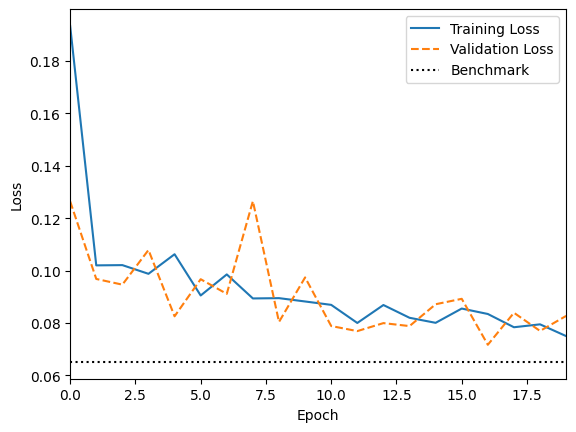

variance of returns for old data:  0.004017612025211478
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.6015)
period from idx:  0  to idx  10
prediction at 10:  tensor(61.4170)
last price from test data:  60.60148620605469
real price 10 steps forward:  tensor(60.8436)
kelly weight:  {tensor(3.3493, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.7468)
period from idx:  10  to idx  20
prediction at 10:  tensor(61.8665)
last price from test data:  tensor(60.7468)
real price 10 steps forward:  tensor(58.3014)
kelly weight:  {tensor(4.5882, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(59.0035)
period from idx:  20  to idx  30
prediction at 10:  tensor(60.1335)
last price from test data:  tensor(59.0035)
real price 10 steps forward:  tensor(59.8267)
kelly weight:  {tensor(4.7667, dtype=torch.float64)}
 
x_

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(54.7423)
period from idx:  60  to idx  70
prediction at 10:  tensor(56.1172)
last price from test data:  tensor(54.7423)
real price 10 steps forward:  tensor(57.6477)
kelly weight:  {tensor(6.2514, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(56.8245)
period from idx:  70  to idx  80
prediction at 10:  tensor(59.0502)
last price from test data:  tensor(56.8245)
real price 10 steps forward:  tensor(54.4760)
kelly weight:  {tensor(9.7491, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(55.4202)
period from idx:  80  to idx  90
prediction at 10:  tensor(57.4969)
last price from test data:  tensor(55.4202)
real price 10 steps forward:  tensor(56.2676)
kelly weight:  {tensor(9.3267, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(54.7665)
period from idx:  90  to idx  100
prediction at 10:  tensor(55.53

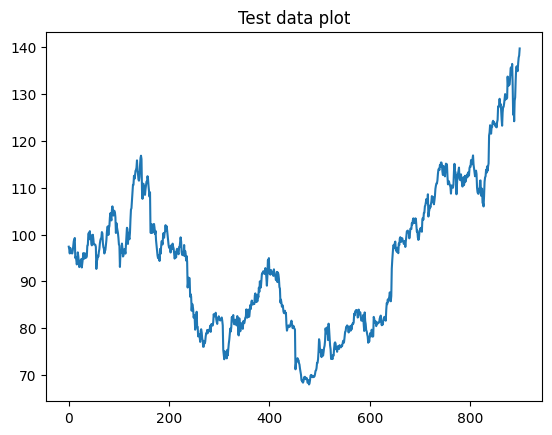

in sequences shape:  (909, 50, 11)
targets shape:  (909, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.9618877418519454
Normalized Benchmark: 0.10061980048024663


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  1.8 M │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

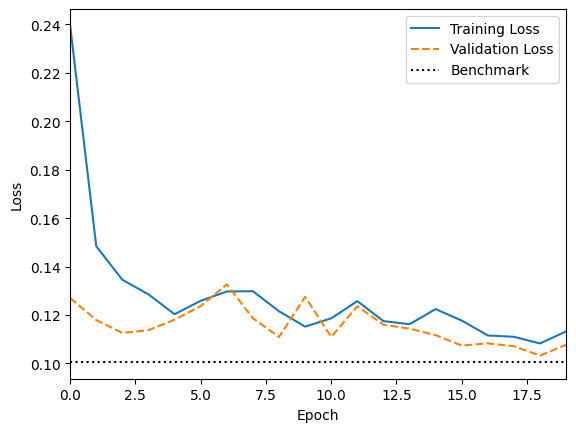

variance of returns for old data:  0.004361029691421634
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.9744)
period from idx:  0  to idx  10
prediction at 10:  tensor(98.3228)
last price from test data:  95.974365234375
real price 10 steps forward:  tensor(98.6032)
kelly weight:  {tensor(5.6108, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.6433)
period from idx:  10  to idx  20
prediction at 10:  tensor(99.1813)
last price from test data:  tensor(97.6433)
real price 10 steps forward:  tensor(94.1876)
kelly weight:  {tensor(3.6117, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.3395)
period from idx:  20  to idx  30
prediction at 10:  tensor(96.4171)
last price from test data:  tensor(95.3395)
real price 10 steps forward:  tensor(95.4163)
kelly weight:  {tensor(2.5917, dtype=torch.float64)}
 
x_in

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.2977)
period from idx:  70  to idx  80
prediction at 10:  tensor(99.1770)
last price from test data:  tensor(97.2977)
real price 10 steps forward:  tensor(101.3678)
kelly weight:  {tensor(4.4289, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(99.9087)
period from idx:  80  to idx  90
prediction at 10:  tensor(101.2042)
last price from test data:  tensor(99.9087)
real price 10 steps forward:  tensor(105.0923)
kelly weight:  {tensor(2.9733, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(104.0556)
period from idx:  90  to idx  100
prediction at 10:  tensor(104.2505)
last price from test data:  tensor(104.0556)
real price 10 steps forward:  tensor(97.8737)
kelly weight:  {tensor(0.4295, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(99.2944)
period from idx:  100  to idx  110
prediction at 10:  tens

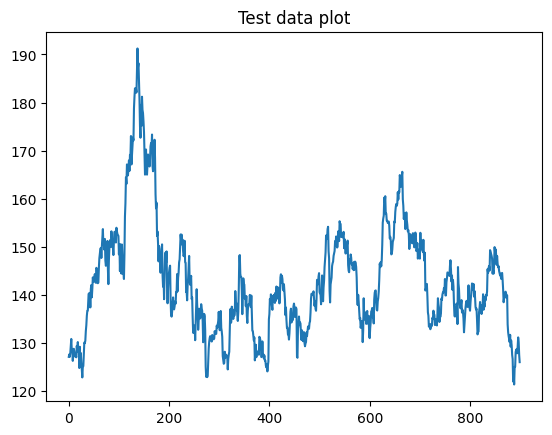

in sequences shape:  (909, 50, 11)
targets shape:  (909, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.0979642951828843
Normalized Benchmark: 0.030145819484514596


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  1.8 M │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

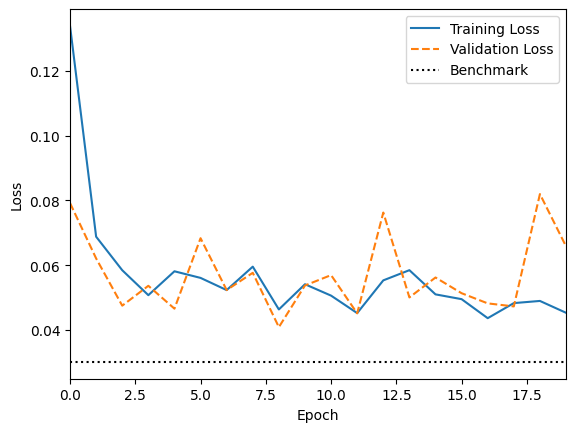

variance of returns for old data:  0.003416352819478145
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(126.4020)
period from idx:  0  to idx  10
prediction at 10:  tensor(129.3224)
last price from test data:  126.4019546508789
real price 10 steps forward:  tensor(128.7307)
kelly weight:  {tensor(6.7629, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(127.7060)
period from idx:  10  to idx  20
prediction at 10:  tensor(125.8813)
last price from test data:  tensor(127.7060)
real price 10 steps forward:  tensor(128.4046)
kelly weight:  {tensor(-4.1823, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(128.3581)
period from idx:  20  to idx  30
prediction at 10:  tensor(124.2580)
last price from test data:  tensor(128.3581)
real price 10 steps forward:  tensor(127.7526)
kelly weight:  {tensor(-9.3499, dtype=torch.f

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(142.1905)
period from idx:  80  to idx  90
prediction at 10:  tensor(137.0287)
last price from test data:  tensor(142.1905)
real price 10 steps forward:  tensor(151.0862)
kelly weight:  {tensor(-10.6260, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(148.2452)
period from idx:  90  to idx  100
prediction at 10:  tensor(141.1324)
last price from test data:  tensor(148.2452)
real price 10 steps forward:  tensor(148.3849)
kelly weight:  {tensor(-14.0441, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(152.2040)
period from idx:  100  to idx  110
prediction at 10:  tensor(144.3701)
last price from test data:  tensor(152.2040)
real price 10 steps forward:  tensor(143.2617)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(144.7987)
period from idx:  110  to idx  120
prediction a

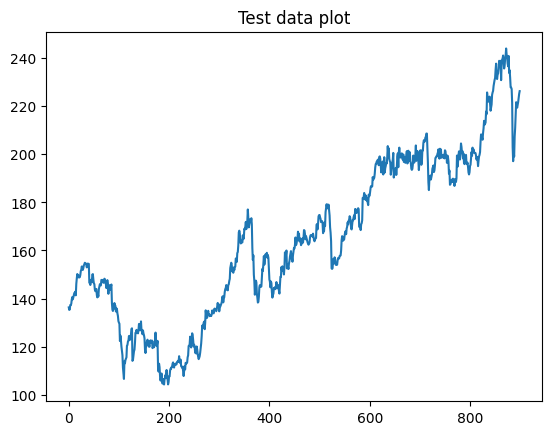

in sequences shape:  (909, 50, 11)
targets shape:  (909, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 2.4864463174878564
Normalized Benchmark: 0.06913733031339214


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  1.8 M │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

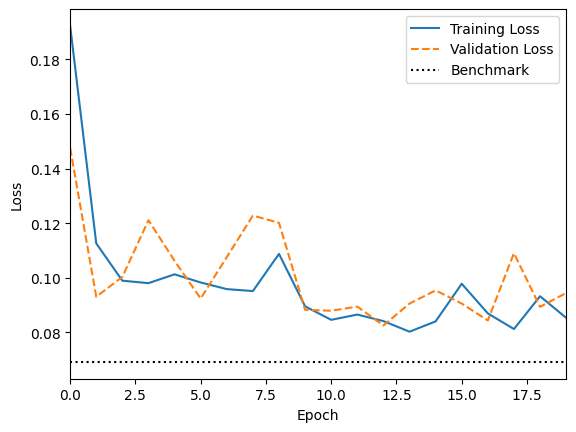

variance of returns for old data:  0.0041415152863393465
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.3259)
period from idx:  0  to idx  10
prediction at 10:  tensor(133.3594)
last price from test data:  135.32594299316406
real price 10 steps forward:  tensor(141.3989)
kelly weight:  {tensor(-3.5089, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(140.3534)
period from idx:  10  to idx  20
prediction at 10:  tensor(136.3763)
last price from test data:  tensor(140.3534)
real price 10 steps forward:  tensor(149.5166)
kelly weight:  {tensor(-6.8421, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(148.8247)
period from idx:  20  to idx  30
prediction at 10:  tensor(142.3419)
last price from test data:  tensor(148.8247)
real price 10 steps forward:  tensor(153.7497)
kelly weight:  {tensor(-10.5179, dtype=tor

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(146.5614)
period from idx:  70  to idx  80
prediction at 10:  tensor(149.7419)
last price from test data:  tensor(146.5614)
real price 10 steps forward:  tensor(145.0598)
kelly weight:  {tensor(5.2398, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(141.9609)
period from idx:  80  to idx  90
prediction at 10:  tensor(146.7795)
last price from test data:  tensor(141.9609)
real price 10 steps forward:  tensor(135.8109)
kelly weight:  {tensor(8.1959, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.8269)
period from idx:  90  to idx  100
prediction at 10:  tensor(144.9473)
last price from test data:  tensor(135.8269)
real price 10 steps forward:  tensor(129.9484)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(130.5874)
period from idx:  100  to idx  110
prediction at 10:  

In [6]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from train.train_functions import plot_training
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'SAAB-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
#tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 20
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=200, num_hidden_layers=7, out_dim=1, dropout=0.1, num_heads=40)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_gru_v1
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)

(5, 900)
(900,)
900


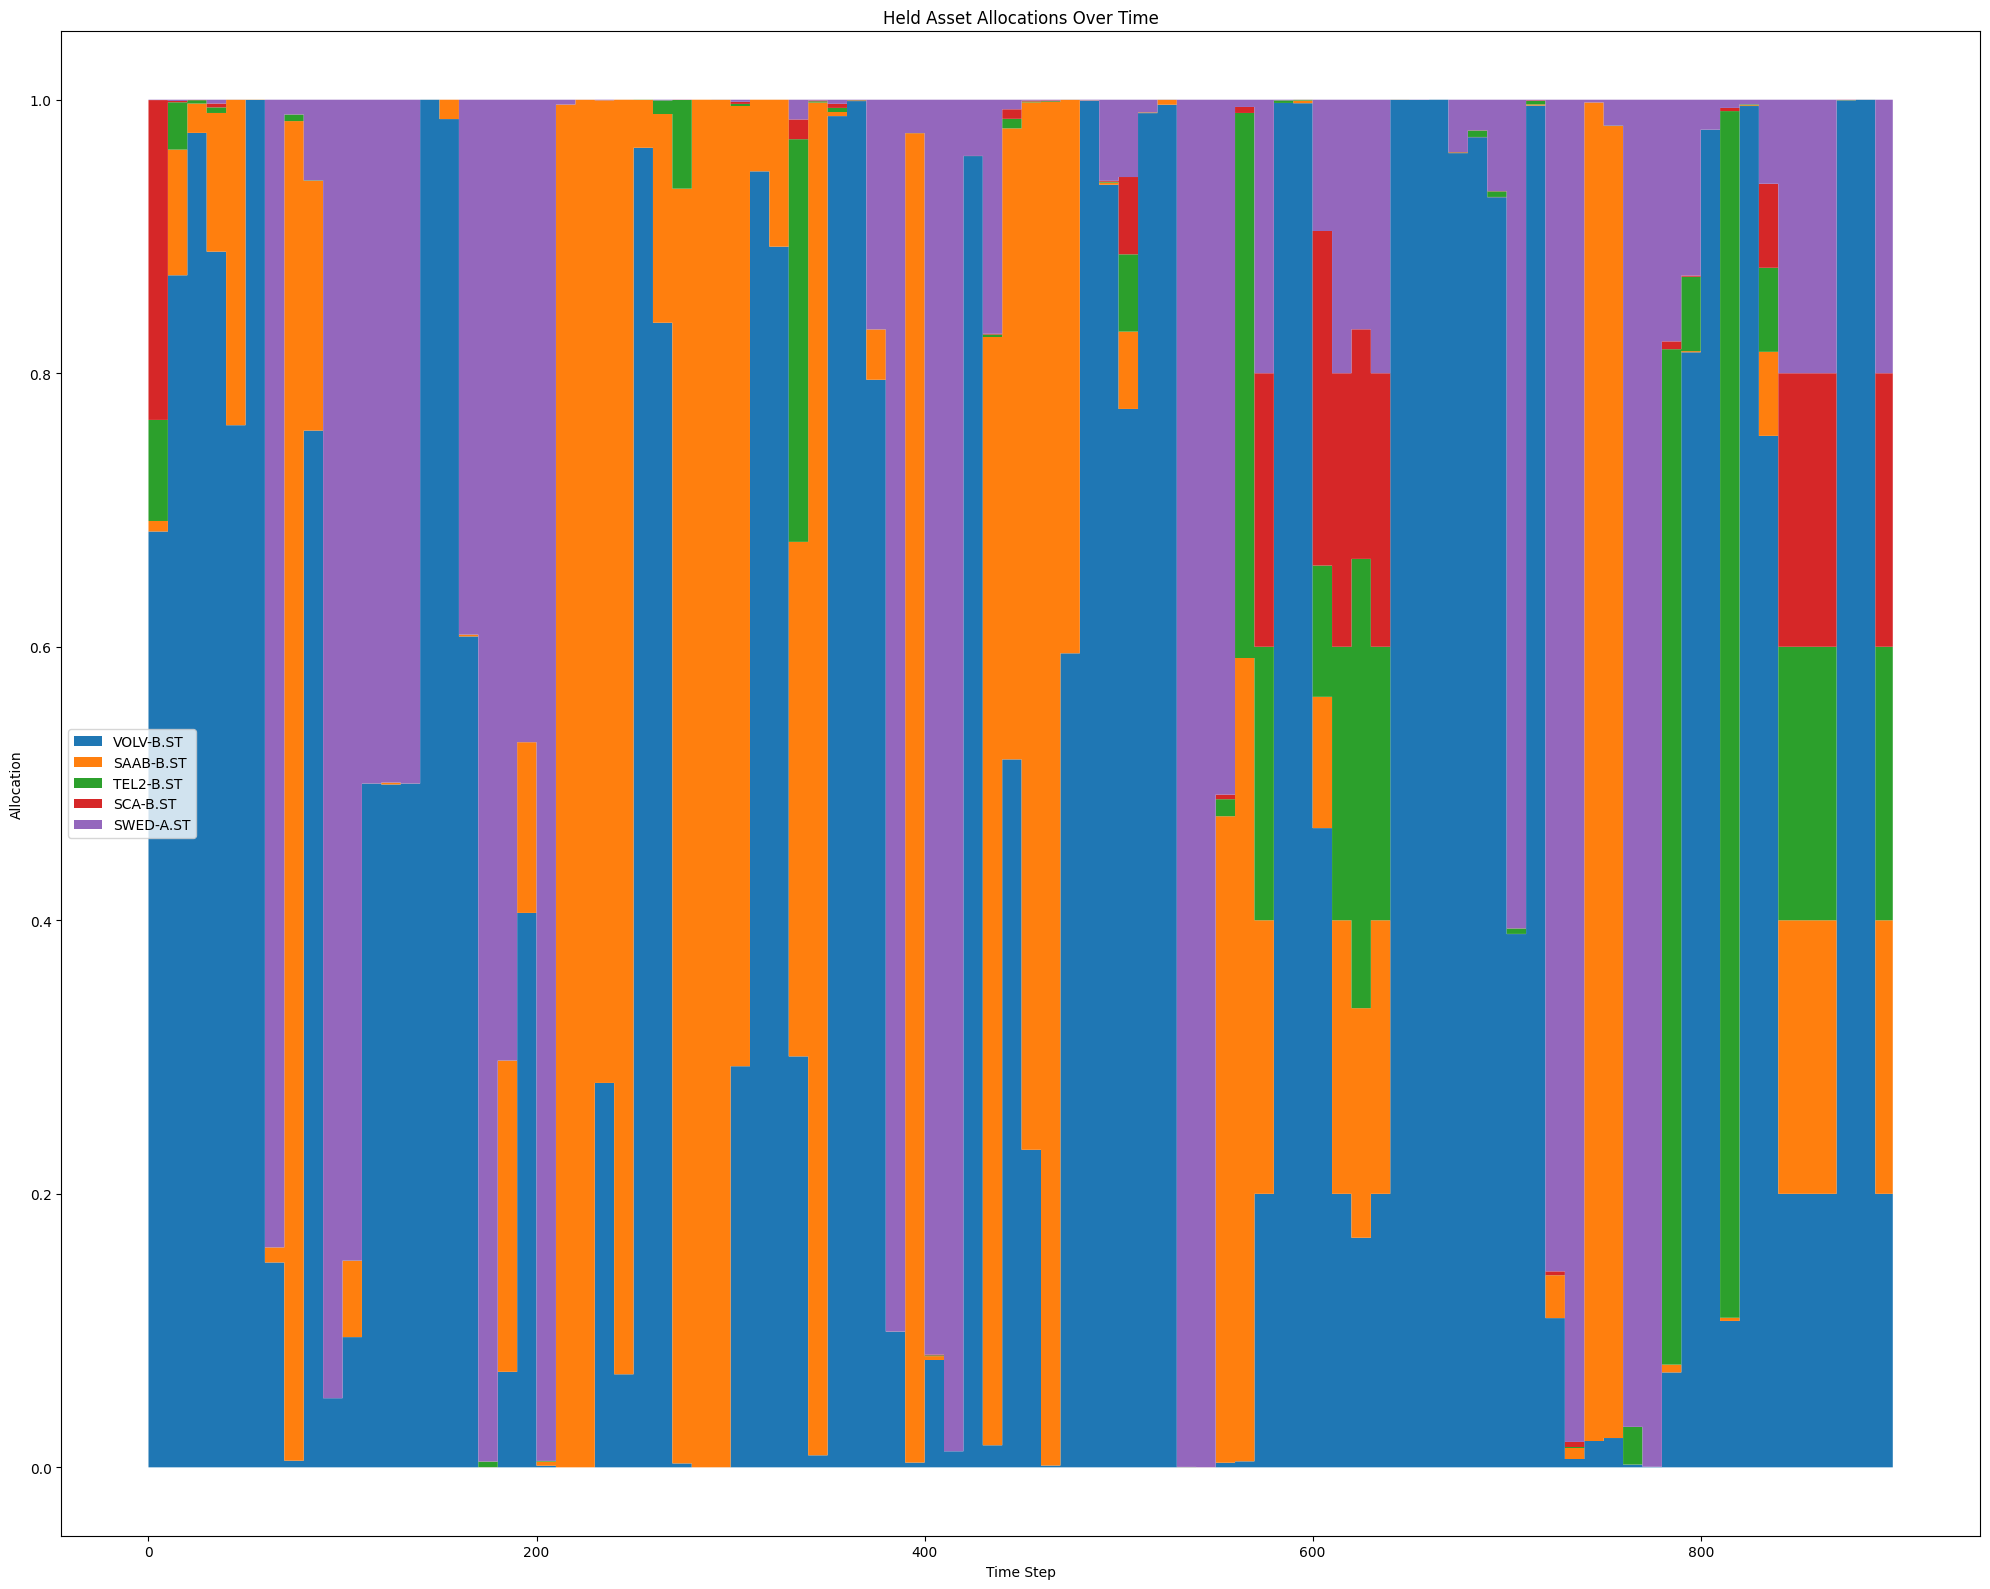

In [10]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_allocations(alloc, tickers)

(5, 900)
(5, 900)
(900,)
Final return:  1.7415887359553925


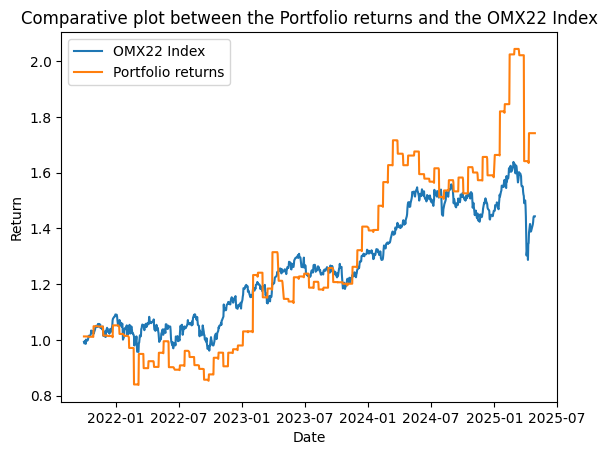

In [11]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt
returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)

portfolio_returns = calculate_portfolio_returns(alloc, returns)
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
#print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Final return: ',portfolio_cum_return[-1])

test_indices = df.index[-900*22::22]

df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values

index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
#print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()


torch.Size([21, 50, 50])
Randomly selected samples: [19, 1, 13, 5]


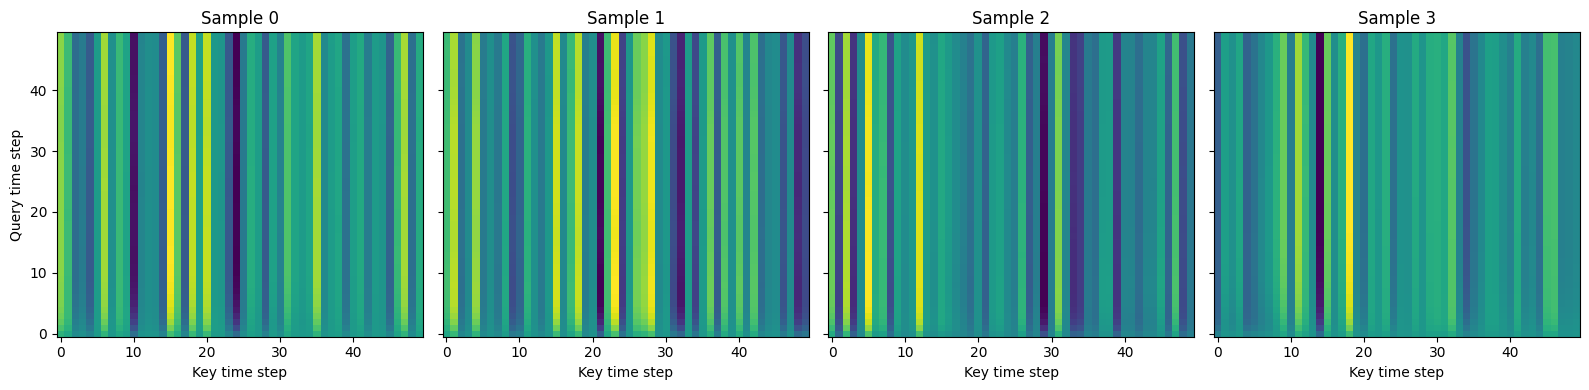

TypeError: Invalid shape (1, 50, 50) for image data

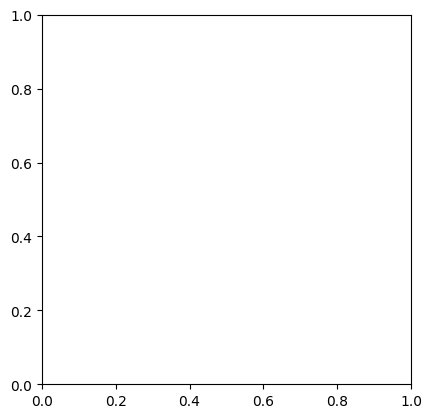

In [12]:
import torch
cross_attn_gru_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_gru_v1(x_batch)
        attn_weights = cross_attn_gru_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()